# Probability-normalized Legendre emulation diagnostics

This notebook studies the constructive root-factorized neural emulator for
\(\psi_n(x)=\sqrt{2n+1}P_n(x)\), orthonormal under \(d\rho=dx/2\) on
\([-1,1]\). Exact values use the stable three-term recurrence; emulated values
use analytic ReLU multiplication networks.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from neural_polynomial_emulation import (
    ReLUSquaringNet,
    basis_error_by_degree,
    emulated_legendre_basis,
    exact_legendre_basis,
    relative_frobenius_mismatch,
)

torch.set_grad_enabled(False)


torch.autograd.grad_mode.set_grad_enabled(mode=False)

## Squaring network

On \([-1,1]\), the analytic bound is \(4^{-L}\), where \(L\) is the number of
sawtooth refinement layers.


In [2]:
x = torch.linspace(-1.0, 1.0, 8193, dtype=torch.float64)
rows = []
for layers in (2, 4, 6, 8, 10, 12):
    net = ReLUSquaringNet(-1.0, 1.0, num_layers=layers)
    error = torch.max(torch.abs(net(x) - x.square())).item()
    rows.append({"num_layers": layers, "sup_error": error, "bound": net.error_bound()})
squaring = pd.DataFrame(rows)
squaring


,num_layers,sup_error,bound
0,2,6.250000e-02,6.250000e-02
1,4,3.906250e-03,3.906250e-03
2,6,2.441406e-04,2.441406e-04
3,8,1.525879e-05,1.525879e-05
4,10,9.536743e-07,9.536743e-07
5,12,5.960464e-08,5.960464e-08


## Degree and depth dependence

The multiplication error is propagated through the sequential product of root
factors. Increasing depth improves low-degree emulation, while conditioning of
the factorization eventually dominates.


In [3]:
rows = []
for layers in (4, 8, 12, 16):
    errors = basis_error_by_degree(16, product="relu", num_layers=layers, grid_size=2001)
    rows.extend(
        {"degree": degree, "num_layers": layers, "sup_error": error}
        for degree, error in enumerate(errors)
    )
errors = pd.DataFrame(rows)
errors.pivot(index="degree", columns="num_layers", values="sup_error")


num_layers,4,8,12,16
degree,,,,
0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,7.247565e-02,2.067182e-04,9.362618e-07,4.299740e-09
3,7.136333e-01,3.070369e-03,1.276717e-05,4.711650e-08
4,6.134571e+00,2.438677e-02,1.068409e-04,4.257706e-07
5,4.167792e+01,2.007284e-01,8.336835e-04,3.332306e-06
6,2.262763e+02,1.759961e+00,6.251628e-03,2.697035e-05
7,3.334125e+03,1.275936e+01,4.807105e-02,2.082855e-04
8,2.520165e+04,9.352558e+01,3.939169e-01,1.671920e-03


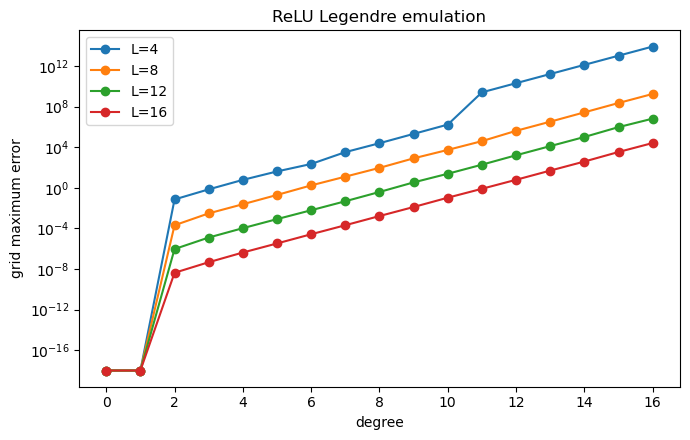

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for layers, group in errors.groupby("num_layers"):
    ax.semilogy(group["degree"], np.maximum(group["sup_error"], 1e-18), marker="o", label=f"L={layers}")
ax.set(xlabel="degree", ylabel="grid maximum error", title="ReLU Legendre emulation")
ax.legend()
fig.tight_layout()
plt.show()


## Measurement-matrix mismatch

The Frobenius mismatch measures the perturbation seen by a downstream
coefficient-recovery method without embedding any recovery solver in this
package.


In [5]:
rng = np.random.default_rng(31415)
samples = rng.uniform(-1.0, 1.0, size=512)
rows = []
for max_degree in (4, 8, 12, 16):
    exact = exact_legendre_basis(samples, max_degree)
    for layers in (8, 12, 16):
        approximate = emulated_legendre_basis(samples, max_degree, product="relu", num_layers=layers).numpy()
        rows.append({
            "max_degree": max_degree,
            "num_layers": layers,
            "relative_frobenius_mismatch": relative_frobenius_mismatch(exact, approximate),
        })
mismatch = pd.DataFrame(rows)
mismatch.pivot(index="max_degree", columns="num_layers", values="relative_frobenius_mismatch")


num_layers,8,12,16
max_degree,,,
4,4.997138e-03,0.000019,7.511838e-08
8,1.629424e+01,0.062829,2.261200e-04
12,5.716508e+04,216.682840,8.820707e-01
16,2.133822e+08,616795.031276,3.029236e+03
